# Face Recognition

## 0. Problem Statement
We intend to perform face recognition. Face recognition means that for a given image you can
tell the subject id. Our database of subject is very simple. It has 40 subjects. Below we will
show the needed steps to achieve the goal of the assignment.

## 1. Imports and Utilities

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
from time import time
from matplotlib import gridspec

## 2. Data Preparation

In [2]:
class FaceDataset:
    def __init__(self, path='dataset', subjects=40, imgs_per_subject=10):
        self.path = path
        self.imgs, self.D, self.y = [], [], []
        self.subjects = subjects
        self.imgs_per_subject = imgs_per_subject
        self.X_test, self.X_train = [], []
        self.y_test, self.y_train = [], []

    def load_data(self):
        self.imgs = [plt.imread(f'{self.path}/s{i + 1}/{j + 1}.pgm') for i in range(self.subjects) for j in range(self.imgs_per_subject)]
        self.imgs = np.array(self.imgs)

    def flatten_data(self):
        self.D = np.array([self.imgs[i].flatten() for i in range(len(self.imgs))])
        self.y = np.array([i + 1 for i in range(self.subjects) for _ in range(self.imgs_per_subject)])

    def split_train_test(self):
        self.X_test, self.X_train = self.D[0::2], self.D[1::2]
        self.y_test, self.y_train = self.y[0::2], self.y[1::2]
        return (self.X_train, self.y_train), (self.X_test, self.y_test)

    def print_sample(self, samples_number=5):
        samples_number *= self.imgs_per_subject

        plt.figure(figsize=(self.imgs_per_subject, samples_number / 2 * 2.5))

        for i, img in enumerate(self.imgs):
            if i == samples_number:
                break
            plt.subplot(samples_number, self.imgs_per_subject, i + 1)
            plt.imshow(img, cmap="gray")
            plt.axis('off')

        plt.tight_layout()
        plt.show()

face_dataset = FaceDataset()

### 2.1.  Download the Dataset

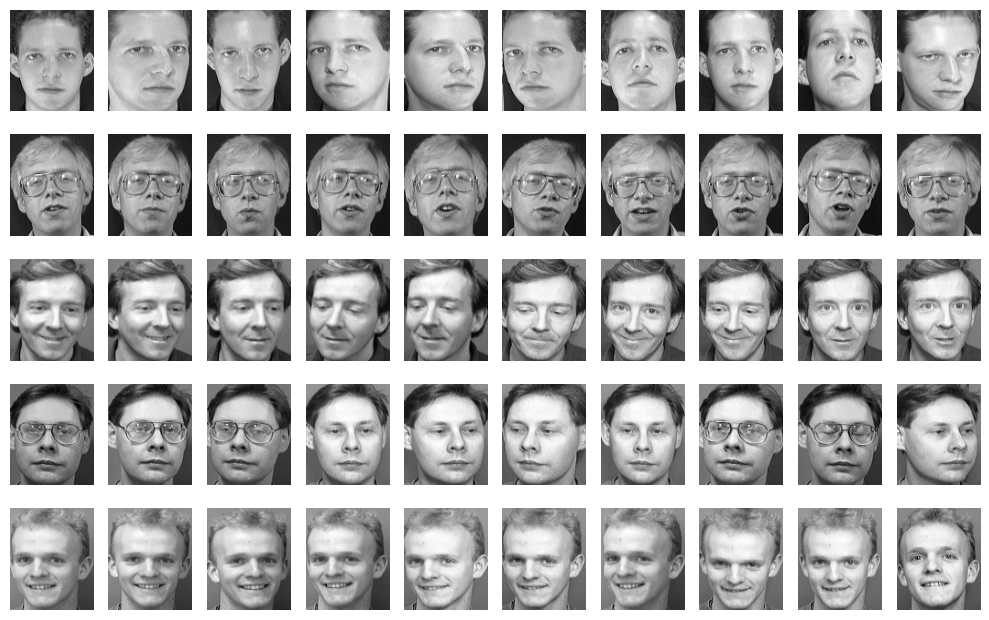

In [3]:
face_dataset.load_data()
face_dataset.print_sample()

### 2.2. Generate the Data Matrix and Label Vector

In [4]:
face_dataset.flatten_data()
print(f"Data Matrix shape: {face_dataset.D.shape}, y shape: {face_dataset.y.shape}")

Data Matrix shape: (400, 10304), y shape: (400,)


### 2.3. Split the Dataset into Training and Test sets

In [5]:
face_dataset.split_train_test()
print(f"Train shape: {face_dataset.X_train.shape}, Test shape: {face_dataset.X_test.shape}")

Train shape: (200, 10304), Test shape: (200, 10304)


In [7]:
X_train = face_dataset.X_train
X_test = face_dataset.X_test
y_train = face_dataset.y_train
y_test = face_dataset.y_test

## 3. PCA Implementation

### 3.0. Pseudocode

* center data by subtracting the mean
* Find directions of maximum variance (principal components)
* Sort components by importantance (eigenvalues)
* Keeping only components needed to achieve certain variance

### 3.1. Compute PCA

In [6]:
class PCA:
    def __init__(self, variance_thresholds=[0.8,0.85,0.9,0.95]):
        self.thresholds = sorted(variance_thresholds)
        self.mean = None
        self.components = None
        self.eigenvalues = None
        self.cumulative_variance = None
        # file to store pca parameters (components,eigenvalues,mean)
        # so that they are computed once for the highest threshold and we use subsets of these components for the lower thresholds
        self.cache_file = 'pca_cache.npz'
        
    def get_pca(self, X):
        # centering the data: by subtracting the mean vector from the data 
        self.mean = np.mean(X, axis=0, dtype=np.float32)
        X_centered = X - self.mean
        
        # computing the covariance matrix
        n_samples = X.shape[0]
        cov = X_centered @ X_centered.T * (1 / n_samples)

        # performing eigenvalue decomposition
        epsilon = 1e-10
        eigen_values, eigen_vectors = np.linalg.eigh(cov)
        eigen_vectors = X_centered.T @ eigen_vectors
        eigen_vectors /= np.linalg.norm(eigen_vectors, axis=0) + epsilon

        # sorting by descending eigenvalue
        i = np.argsort(eigen_values)[::-1]
        return eigen_values[i],eigen_vectors[:,i]
    
    def fit(self, X, is_computed=False):
        # if we have computed and cached the results before just load them
        if is_computed and os.path.exists(self.cache_file):
            cache = np.load(self.cache_file)
            self.eigenvalues = cache['eigenvalues']
            self.components = cache['components']
            self.mean = cache['mean']
        # otherwise compute PCA from scratch
        else:
            start = time()
            eigen_values, eigen_vectors = self.get_pca(X)
            self.eigenvalues = eigen_values.astype(np.float32)
            
            # eigenvalues = variance along each principal component
            # total variance = sum of eigenvalues
            total_variance = np.sum(eigen_values)

            # compute how much variance we keep as we add components
            # using comulative sum
            explained_variance = np.cumsum(eigen_values) / total_variance
            
            # finding how many components we need to keep the maximum requested variance
            max_components = np.argmax(explained_variance >= max(self.thresholds)) + 1 # +1 to convert from 0 based index to component count
            self.components = eigen_vectors[:,:max_components].astype(np.float32)
            
            # saving results to cache file for faster future runs
            np.savez(self.cache_file, 
                    eigenvalues=self.eigenvalues,
                    components=self.components,
                    mean=self.mean)
            
            print(f"PCA computed in {time()-start:.4f}s")
        
        # final calculations needed for all thresholds
        total_variance = np.sum(self.eigenvalues)
        self.cumulative_variance = np.cumsum(self.eigenvalues) / total_variance
        
        return self
    
    def get_components(self, threshold):
        # gets the components needed for specific variance
        n_components = np.argmax(self.cumulative_variance >= threshold) + 1
        return self.components[:, :n_components]
    
    def transform(self, X, threshold):
        # project data onto the principal components
        components = self.get_components(threshold)
        return (X - self.mean) @ components
    
    # reporting dimensionality
    def report_results(self):
        print("PCA dimentionality report")
        print("-"*45)
        print("{:<10} {:<15} {:<20}".format("Threshold","Components","Variance retained"))
        print("-"*45)

        for i in self.thresholds:
            n_comp = np.argmax(self.cumulative_variance >= i) + 1
            var_retained = self.cumulative_variance[n_comp-1]
            print("{:<10.2f} {:<15} {:<20.4f}".format(i,n_comp,var_retained))

### 3.2. Project Data

In [8]:
pca = PCA(variance_thresholds=[0.8,0.85,0.9,0.95])
# computing pca for training data
pca.fit(X_train)

# report dimensionality
pca.report_results()

PCA computed in 0.0536s
PCA dimentionality report
---------------------------------------------
Threshold  Components      Variance retained   
---------------------------------------------
0.80       37              0.8028              
0.85       53              0.8521              
0.90       77              0.9006              
0.95       116             0.9500              


In [9]:
# dictionary to store all reduced datasets
projected_data = {}

# reducing dimensions of both training and test data for each threshold
for i in pca.thresholds:
    X_train_pca = pca.transform(X_train, i)
    X_test_pca = pca.transform(X_test, i)
    projected_data[i] = {
        'train':X_train_pca,
        'test':X_test_pca
    }
    print(f"\nThreshold {i}: Train shape {X_train_pca.shape}, Test shape {X_test_pca.shape}")


Threshold 0.8: Train shape (200, 37), Test shape (200, 37)

Threshold 0.85: Train shape (200, 53), Test shape (200, 53)

Threshold 0.9: Train shape (200, 77), Test shape (200, 77)

Threshold 0.95: Train shape (200, 116), Test shape (200, 116)


### 3.3. Visualization

## 4. Unsupervised Clustering

### 4.1. K-Means Clustering

#### 4.1.1. K-Means Implementation

#### 4.1.2. Evaluation

#### 4.1.3. Analysis

### 4.2. Gaussian Mixture Model Clustering

#### 4.2.1. GMM Implementation

#### 4.2.2. Evaluation

#### 4.2.3. Analysis

## 5. Evaluation

### 5.1. Best K-Means Model

### 5.2. Best GMM Model

### 5.3. Comparison
Compare K-Means vs GMM in this cell

## 6. Autoencoder for Dimensionality Reduction

### 6.1. Autoencoder Implementation

### 6.2. Clustering on Autoencoder Features

### 6.3. Comparison

### 6.4. Visualization